In [1]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

In [6]:
MIN_MATCH_COUNT = 10
 
     # queryImage

"""birdArray = ['bird_clean.png' , 'croppedbird.png', 'bird4.png']"""
birdArray = ['1.png']

218
3184


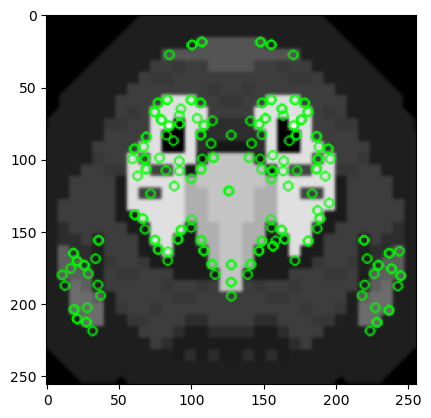

20


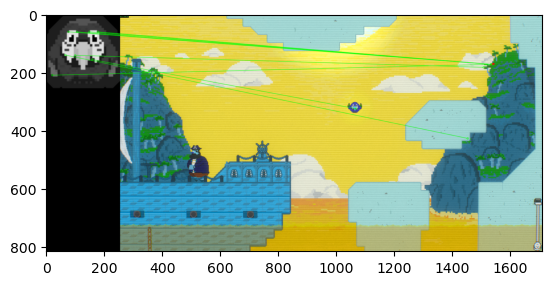

In [9]:
for filename in birdArray:

    img1 = cv.imread(filename, cv.IMREAD_GRAYSCALE)

    img1 = cv.GaussianBlur(img1, (1,1), 0)

    img2 = cv.imread('test_image.png')### replace with test image ####, cv.IMREAD_GRAYSCALE) # trainImage

    img1 = cv.GaussianBlur(img1, (5,5), 0)

    #-----------------------------------------------------------------------
    # Initiate SIFT detector


    # orb = cv.ORB_create()
    
    # # find the keypoints with ORB
    # kp1 = orb.detect(img1,None)
    # kp2 = orb.detect(img2,None)
    
    # # compute the descriptors with ORB
    # kp1, des1 = orb.compute(img1, kp1)
    # kp2, des2 = orb.compute(img2, kp2)


    #-----------------------------------------------------------------------
    
    # # draw only keypoints location,not size and orientation

    #-----------------------------------------------------------------------
    # Initiate SIFT detector
    sift = cv.SIFT_create()
    
    # find the keypoints and descriptors with SIFT
    kp1, des1 = sift.detectAndCompute(img1,None)
    print(len(kp1))
    kp2, des2 = sift.detectAndCompute(img2,None)
    print(len(kp2))
    #-----------------------------------------------------------------------

    test = cv.drawKeypoints(img1, kp1, None, color=(0,255,0), flags=0)
    #print(len(kp1))
    plt.imshow(test), plt.show()

    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
    search_params = dict(checks = 50)
    
    flann = cv.FlannBasedMatcher(index_params, search_params)
    
    matches = flann.knnMatch(des1,des2,k=2)

    # store all the good matches as per Lowe's ratio test.
    good = []
    for m,n in matches:
        if m.distance < 0.8*n.distance:
            good.append(m)

    print(len(good))

    if len(good)>MIN_MATCH_COUNT:
        src_pts = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
        dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)
    
        M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC,5.0)
        matchesMask = mask.ravel().tolist()
    
        h,w = img1.shape
        pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2)
        dst = cv.perspectiveTransform(pts,M)
    
        img2 = cv.polylines(img2,[np.int32(dst)],True,255,3, cv.LINE_AA)
    
    else:
        print( "Not enough matches are found - {}/{}".format(len(good), MIN_MATCH_COUNT) )
        matchesMask = None


    draw_params = dict(matchColor = (0,255,0), # draw matches in green color
                    singlePointColor = None,
                    matchesMask = matchesMask, # draw only inliers
                    flags = 2)
    
    img3 = cv.drawMatches(img1,kp1,img2,kp2,good,None,**draw_params)
    
    plt.imshow(img3, 'gray'),plt.show()